In [1]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
import ysy_plot_utils as ypu

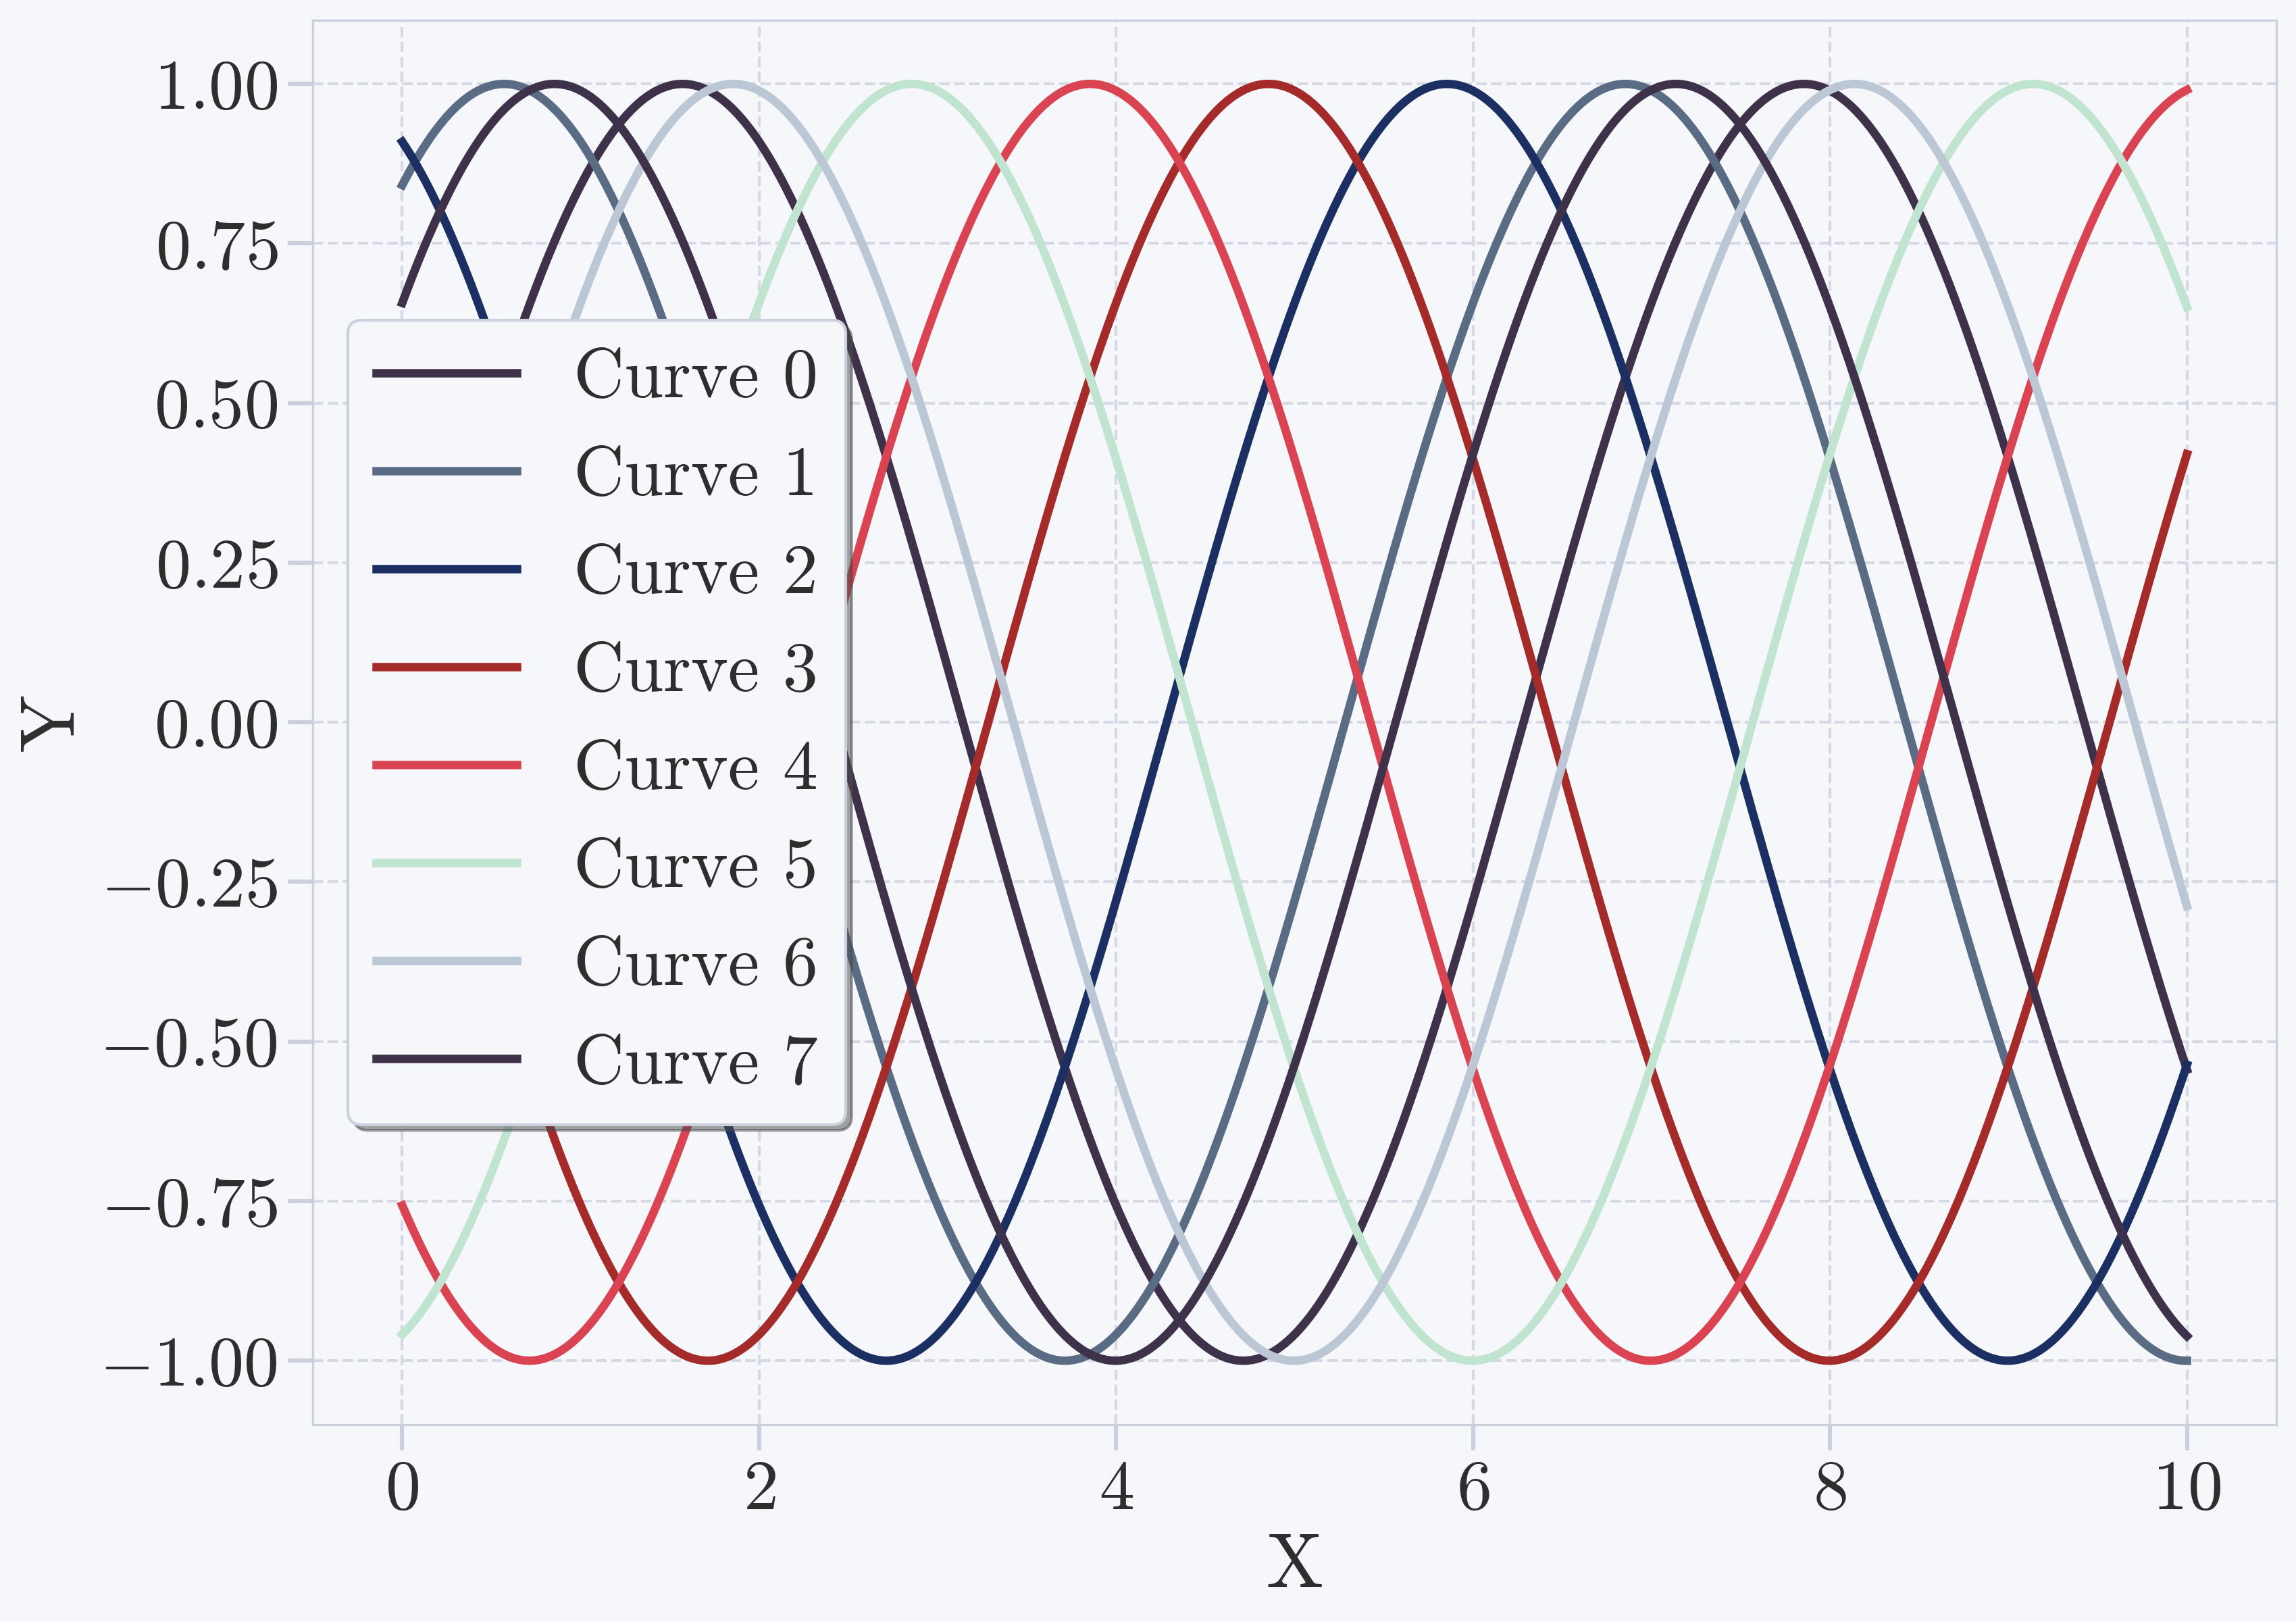

In [ ]:
with ypu.temp_style(["ysy_common"], """

                    
"""):
    x = np.linspace(0, 10, 1000)
    plt.figure(dpi=300)
    for i in range(0, 8):
        plt.plot(x, np.sin(x + i), label='Curve '+str(i))
    plt.legend()
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.show()

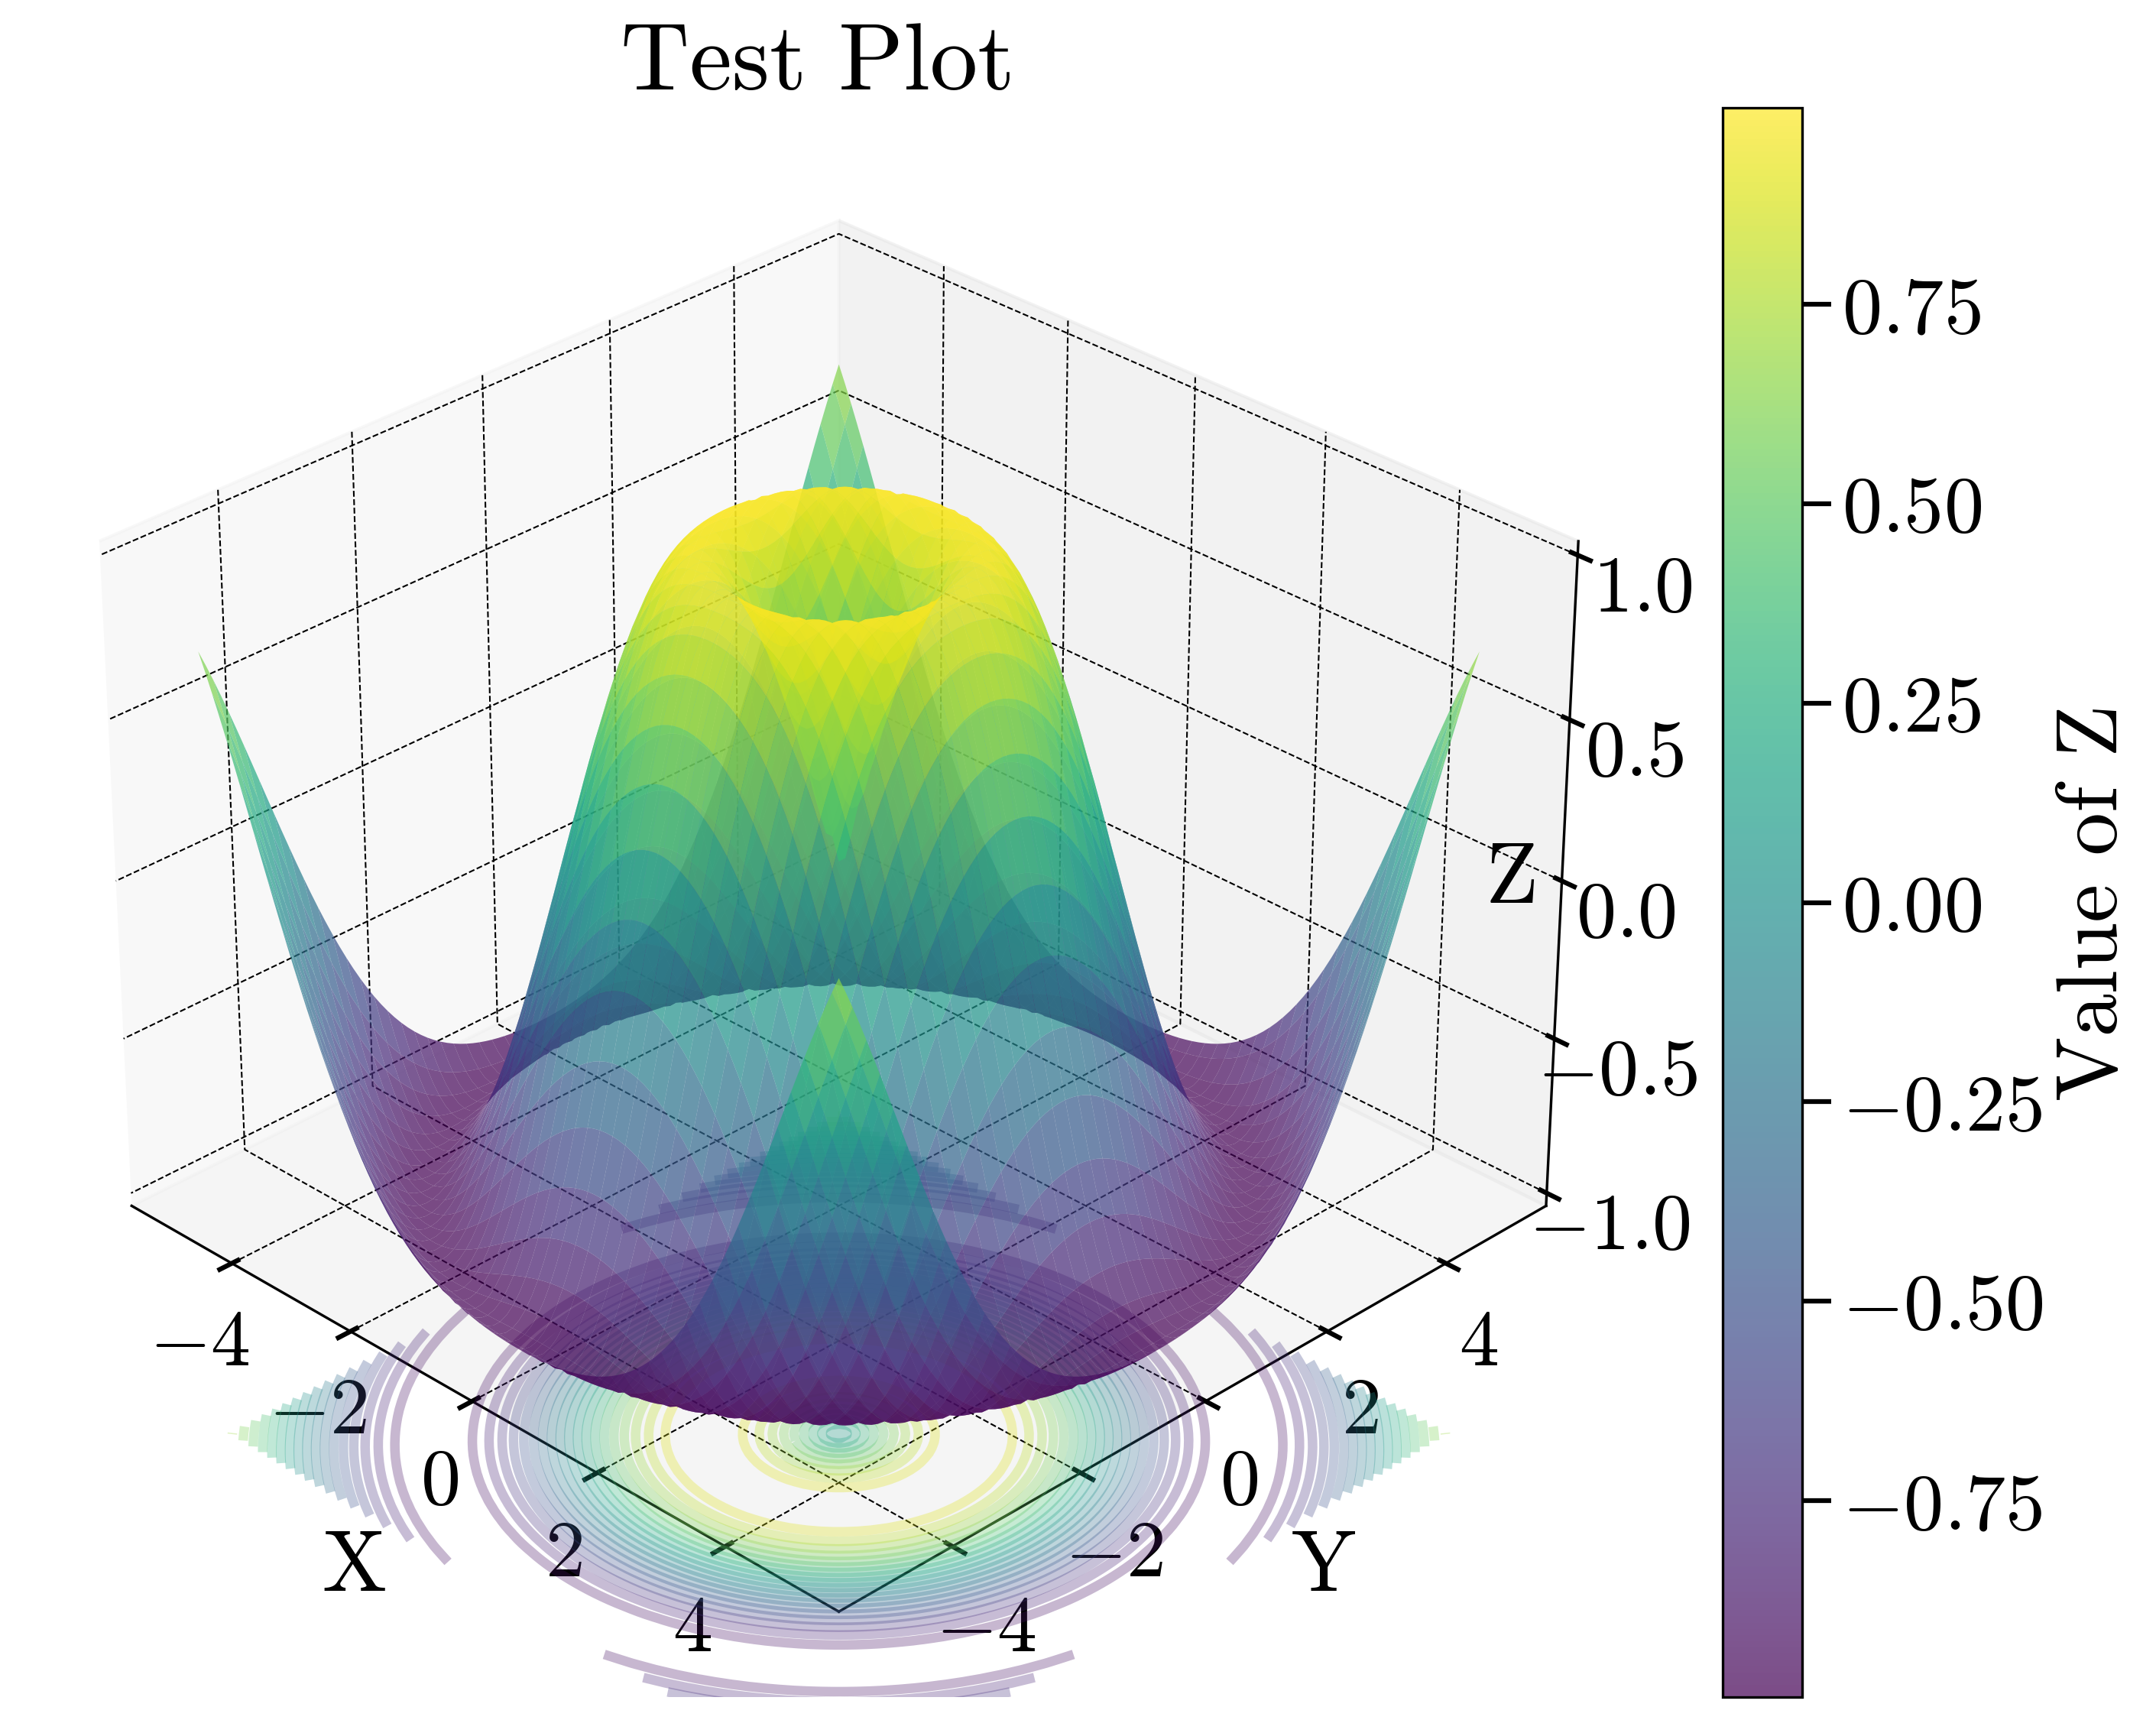

In [7]:
from matplotlib.colors import LinearSegmentedColormap
from cycler import cycler

In [ ]:
# 开发v2版本的流萤主题配色

# 

def liuyin_color_theme(cmap_or_cycle=None, dark_or_light='dark', color_sample_num=10, set_color_cycle=True):
    """
    Generates and applies a custom color theme inspired by the 'Firefly Gallery' project.

    This function provides an option to create either a color map or a color cycle based on the 'Firefly' theme.
    The theme is designed to work in both dark and light modes, allowing users to select the appropriate theme 
    based on their preference. The function also supports automatically updating Matplotlib's color cycle.

    Args:
        cmap_or_cycle (str, optional): Determines the output of the function.
            - `'cycle'`: Returns a list of sampled colors for use as a color cycle.
            - `'cmap'`: Returns the generated color map.
            - `None`: No output, just updates the Matplotlib color cycle if `set_color_cycle` is True.
        dark_or_light (str, optional): Specifies the color theme to use.
            - `'dark'` (default): Uses the dark theme with colors `#FF8B4D` and `#5AFFCC`.
            - `'light'`: Uses the light theme with colors `#FF7C3A` and `#1AFFB2`.
        color_sample_num (int, optional): The number of colors to sample from the colormap. Default is 10.
        set_color_cycle (bool, optional): If `True`, the function updates Matplotlib's color cycle with the generated colors. Default is `True`.

    Returns:
        list or LinearSegmentedColormap or None: 
            - A list of colors if `cmap_or_cycle` is `'cycle'`.
            - A `LinearSegmentedColormap` if `cmap_or_cycle` is `'cmap'`.
            - `None` if no output is requested but the color cycle is updated in Matplotlib.

    Example:
        >>> from your_module import liuyin_color_theme
        >>> liuyin_color_theme('cycle')  # Get color cycle
        >>> liuyin_color_theme('cmap')   # Get color map
        >>> liuyin_color_theme(set_color_cycle=True)  # Automatically apply color cycle to Matplotlib

    Notes:
        - To apply the generated color cycle to Matplotlib, ensure that this function is called after `ysy_settings`.
        - The colors are sampled from a linear gradient colormap created using two sets of colors, one for dark and one for light themes.

    """
    # 定义深色和浅色主题的颜色
    dark_colors = ["#FF8B4D", "#5AFFCC"]  # 深色主题
    light_colors = ["#FF7C3A", "#1AFFB2"]  # 浅色主题
    # 根据选择的主题设置主题颜色
    theme_colors = dark_colors
    if dark_or_light == 'light':  # 如果用户选择了浅色主题
        theme_colors = light_colors
    # 创建自定义的线性渐变 colormap，基于主题颜色
    liuyin_cmap = LinearSegmentedColormap.from_list("liuyin_theme", theme_colors)
    # 从渐变 colormap 中采样一定数量的颜色作为颜色循环
    liuyin_cycle = [liuyin_cmap(i / (color_sample_num - 1)) for i in range(color_sample_num)]
    # 设置颜色循环配置
    add_color = {'axes.prop_cycle': cycler('color', liuyin_cycle)}
    # 如果需要设置颜色循环，更新 Matplotlib 的 rcParams
    if set_color_cycle:
        plt.rcParams.update(add_color)
    # 根据 cmap_or_cycle 参数返回不同的结果
    if cmap_or_cycle == 'cycle':
        return liuyin_cycle  # 返回颜色循环
    elif cmap_or_cycle == 'cmap':
        return liuyin_cmap  # 返回 colormap
    return None  # 如果没有特定要求，返回 None

In [9]:
liuyin_color_theme()

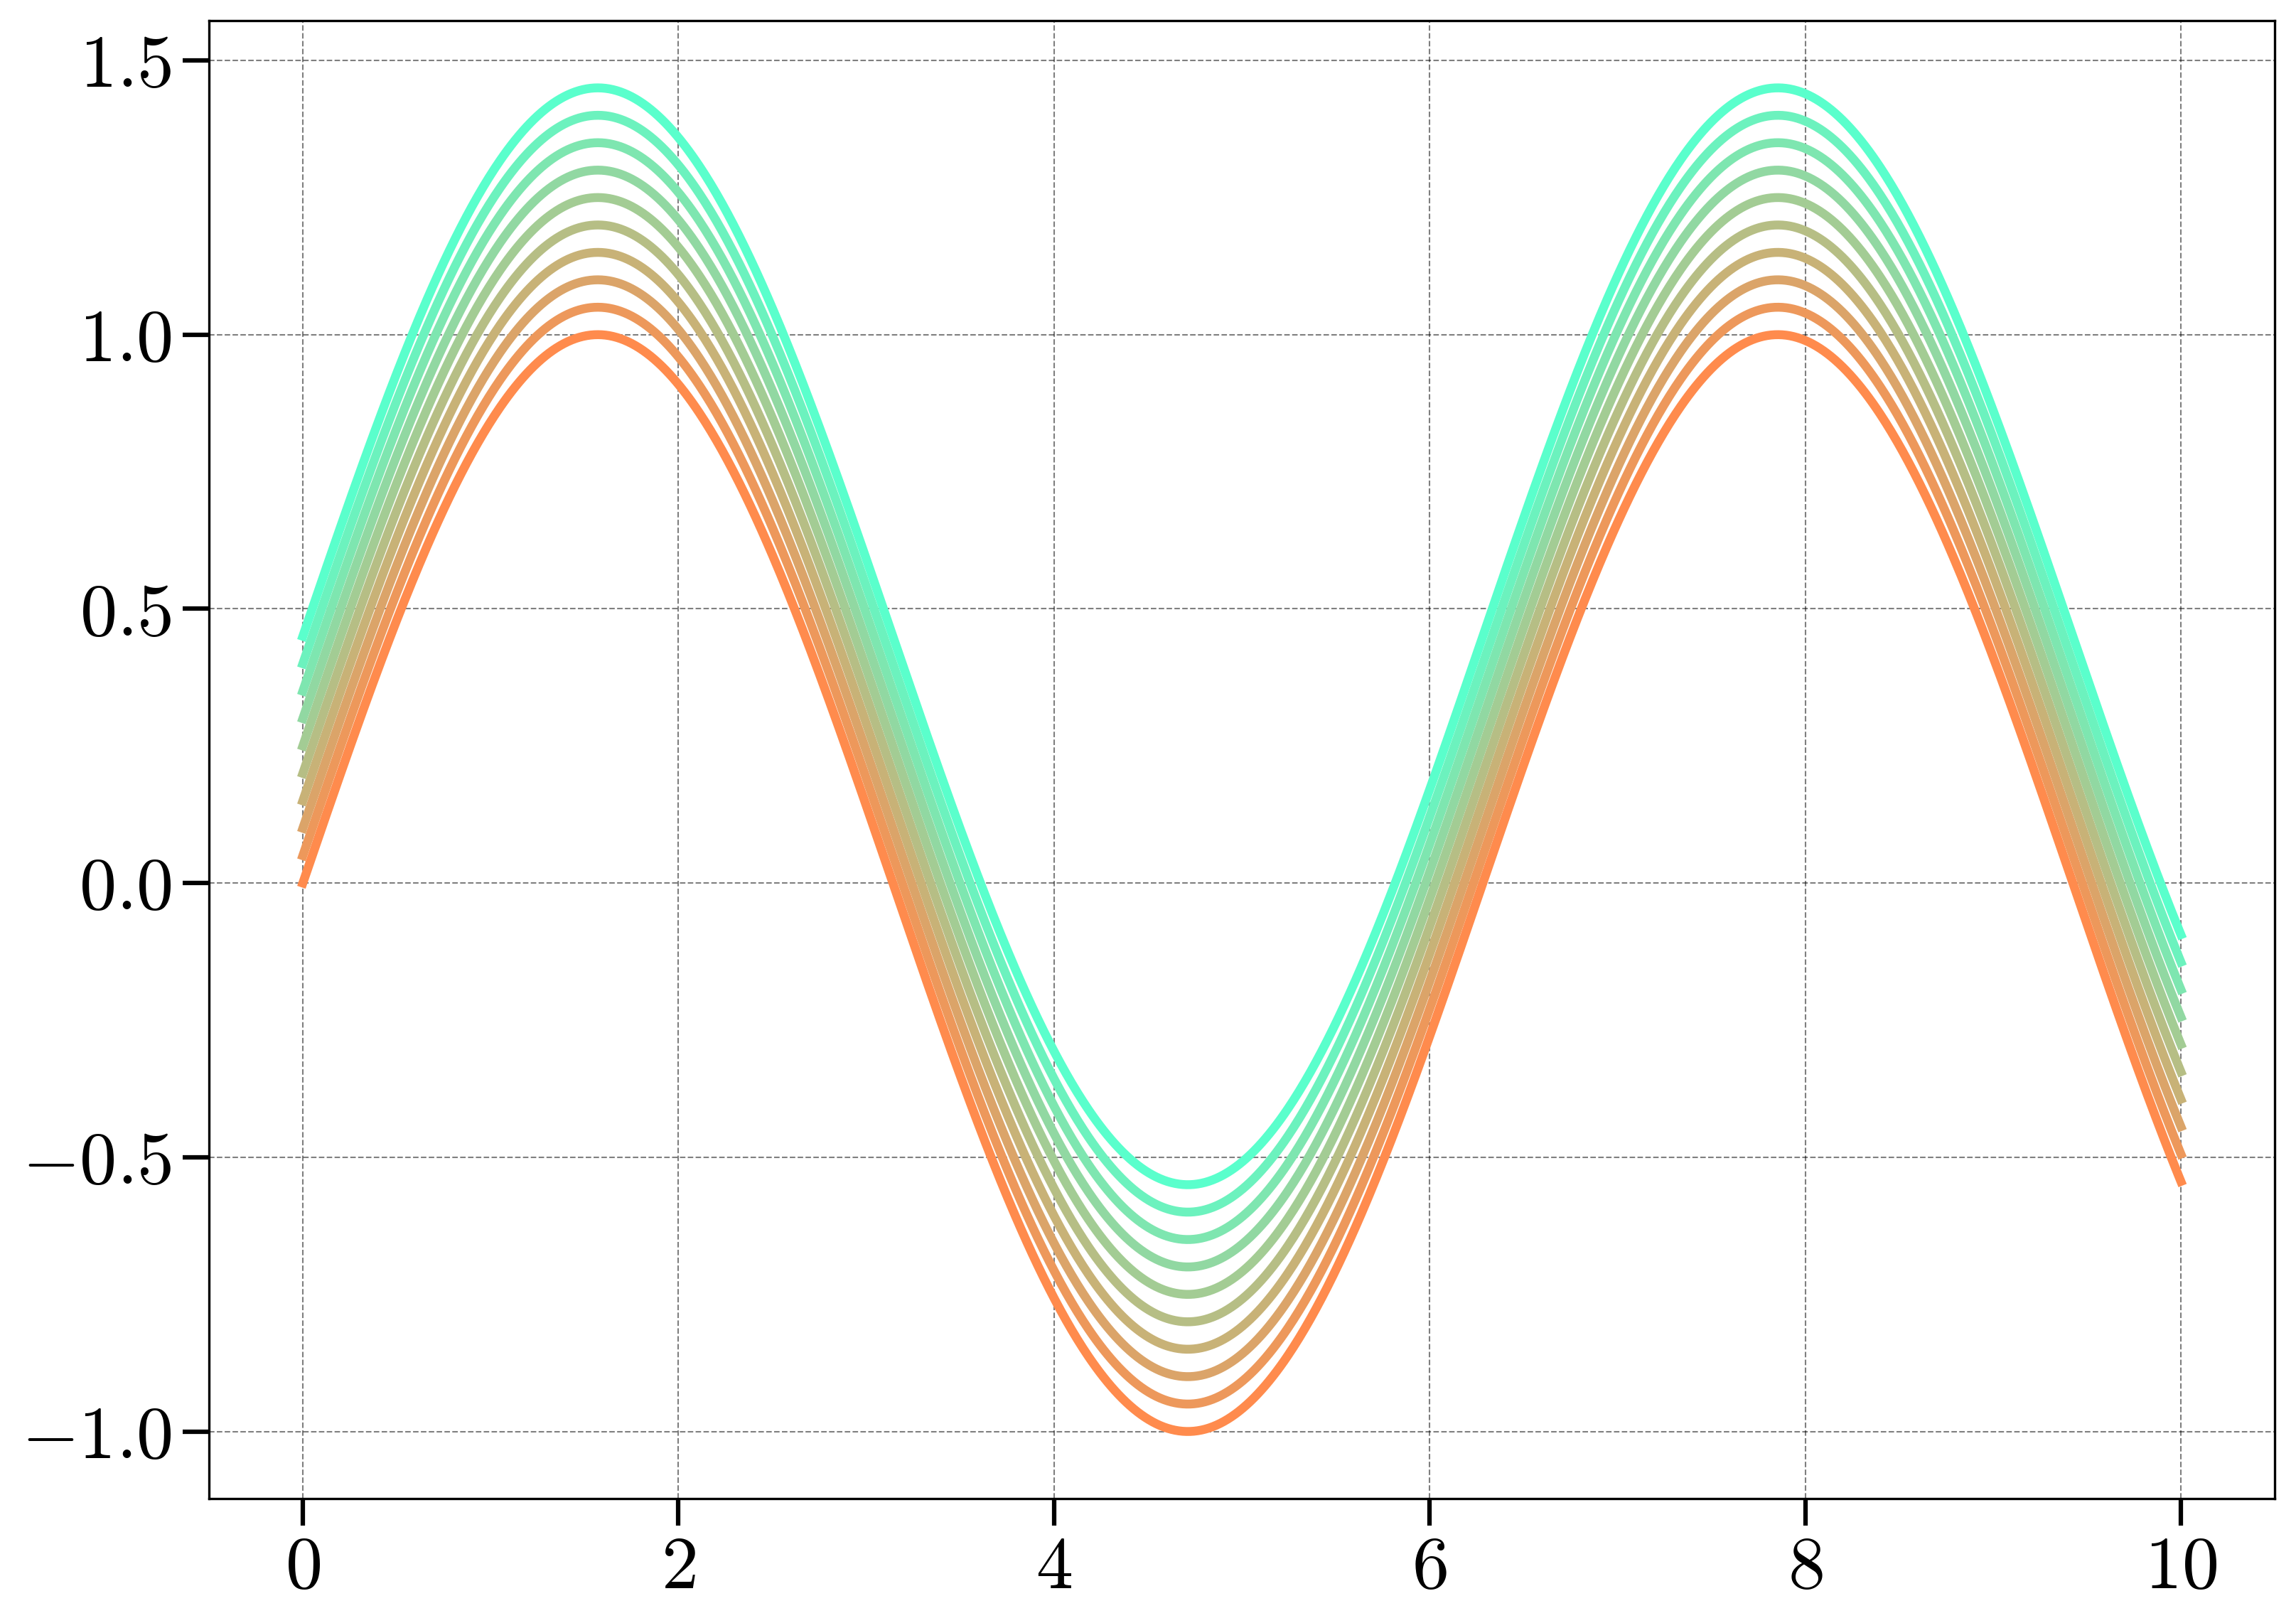

In [12]:
x = np.linspace(0, 10, 1000)
plt.figure()
for i in range(0, 10):
    plt.plot(x, np.sin(x) + 0.05*i)
plt.show()

In [24]:
liuyin_cmap = liuyin_color_theme(cmap_or_cycle='cmap')

def universal_3d(x, y, z, plot_title='', x_label='X', y_label='Y', z_label='Z', view=(30, -45), colorbar=False, contour=False):
    '''
    '''
    #
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    #
    x, y = np.meshgrid(x, y)
    surf = ax.plot_surface(x, y, z, alpha=0.7, cmap=liuyin_cmap)

    #
    ax.set_title(plot_title)
    ax.set_xlabel(x_label, labelpad=20)
    ax.set_ylabel(y_label, labelpad=20)
    ax.set_zlabel(z_label, labelpad=-30)
    ax.view_init(elev=view[0], azim=view[1])

    #
    if colorbar:
        cbar = fig.colorbar(surf)
        cbar.set_label('Value of '+ z_label)  # 设置 colorbar 标签

    #
    if contour:
        contour_location = np.min(z) + 0.4*(np.min(z) - np.max(z))
        ax.contour(x, y, z, 20, cmap=liuyin_cmap, offset=contour_location, alpha=0.3)  # offset=-1表示等高线绘制在Z=-1的位置
    
    #
    plt.show()
    return None

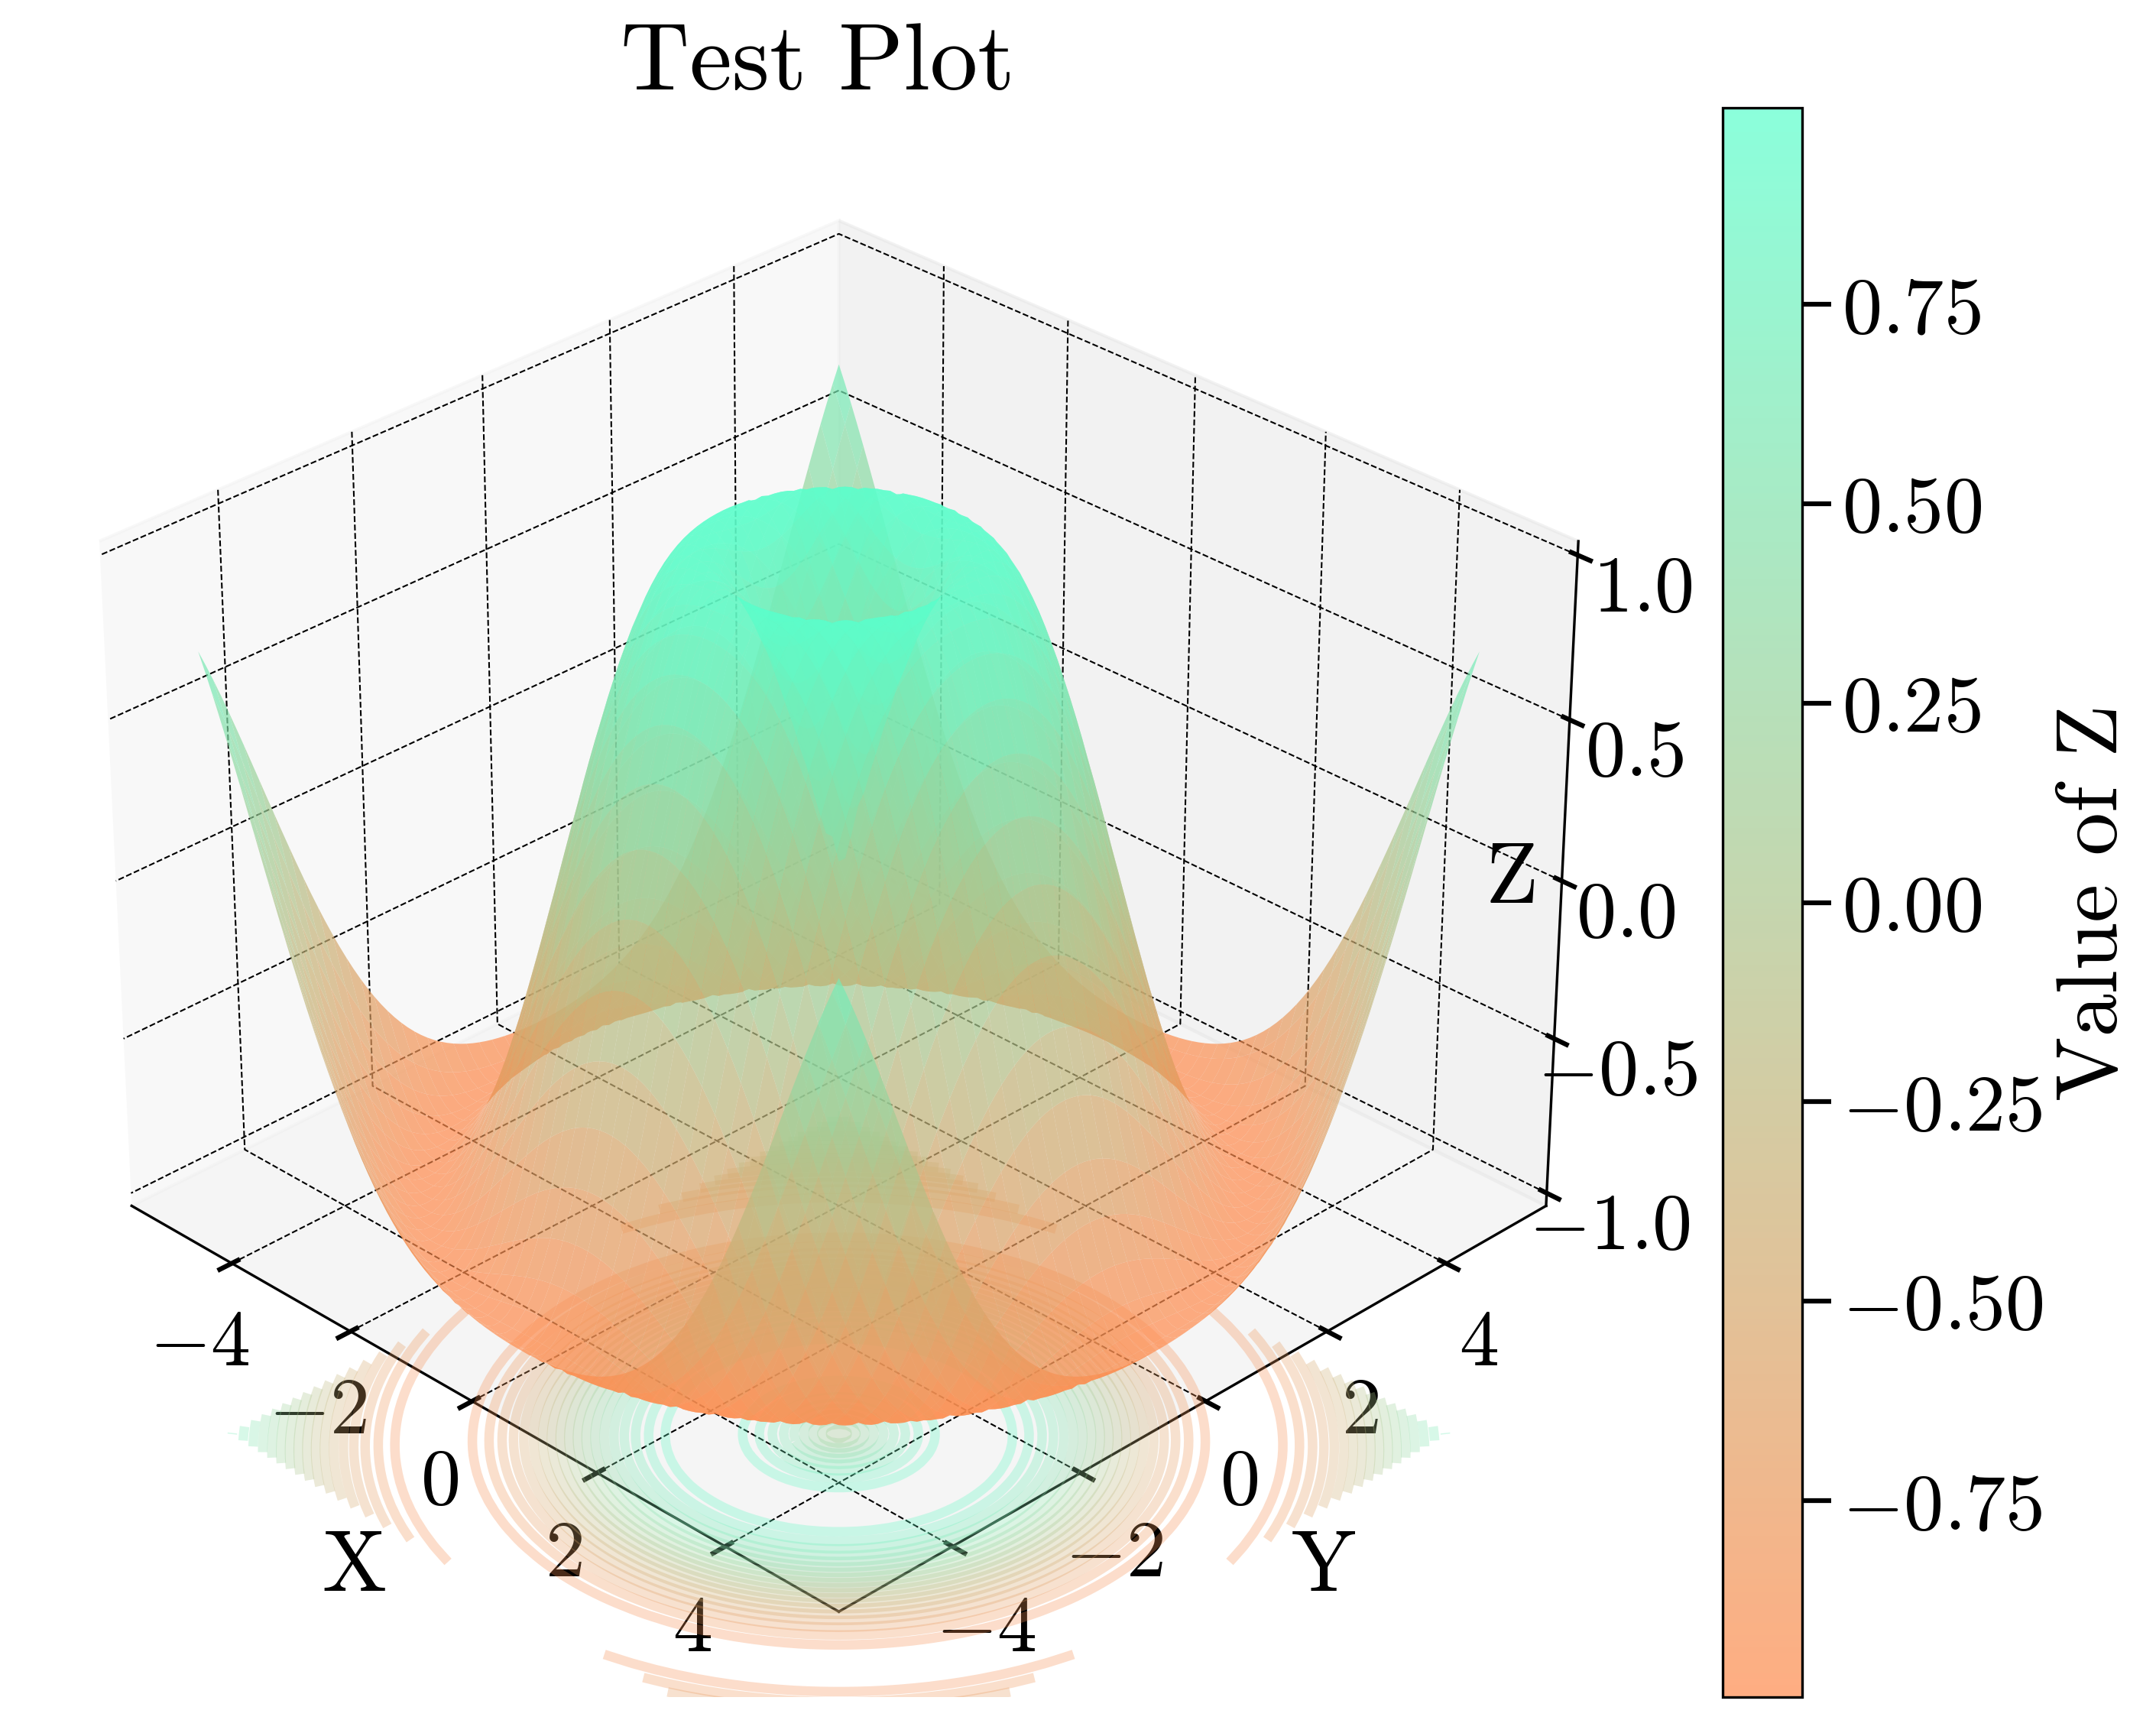

In [25]:
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
x, y = np.meshgrid(x, y)
z = np.sin(np.sqrt(x**2 + y**2))
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
universal_3d(x, y, z, colorbar=True, plot_title='Test Plot', contour=True)

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# 定义渐变配色方案：
# 深色主题：从 #FF8B4D 到 #5AFFCC
# 浅色主题：从 #FF7C3A 到 #1AFFB2
dark_colors = ["#FF8B4D", "#5AFFCC"]
light_colors = ["#FF7C3A", "#1AFFB2"]

# 选择主题（此处选择深色主题）
theme_colors = light_colors  # 若需浅色主题，改为 light_colors

# 创建自定义的线性渐变 colormap
flowing_cmap = LinearSegmentedColormap.from_list("flowing_theme", theme_colors)

# 注册该 colormap（这样以后在 imshow 等函数中也可直接使用）
mpl.colormaps.register(flowing_cmap)

# 设置默认的图像 colormap 为自定义渐变色（可选）
mpl.rcParams["image.cmap"] = "flowing_theme"

# 从渐变 colormap 中采样一定数量的颜色作为默认的颜色循环
num_colors = 10  # 可根据需要调整采样数量
color_cycle = [flowing_cmap(i/(num_colors - 1)) for i in range(num_colors)]

# 设置 matplotlib 默认颜色循环
mpl.rcParams["axes.prop_cycle"] = mpl.cycler(color=color_cycle)

# 示例：绘制一组正弦曲线，观察渐变配色效果
x = np.linspace(0, 10, 300)
plt.figure(figsize=(8, 4))
for i in range(num_colors):
    plt.plot(x, np.sin(x + i * 0.2), label=f"Line {i+1}")

plt.legend(loc='upper right')
plt.title("Example Plot with Flowing Gradient Colors")
plt.xlabel("X Axis")
plt.ylabel("Y Axis")
plt.tight_layout()
plt.show()
